# Imports

In [1]:
import pandas as pd
import numpy as np

# Get and Format Data

In [2]:
def prepare_data(data, year):
    data = data.rename(columns=lambda x: x[2:] if x[1]=='_' else x)
    data['year'] = year
    data = data.sample(frac=1)
    return data

In [3]:
amazon_train_sets = [prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/types/tropical/amazon_train_{year}.csv"), year) for year in range(2022, 2025)]
amazon_train = pd.concat(amazon_train_sets, axis=0)

borneo_train_sets = [prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/types/tropical/borneo_train_{year}.csv"), year) for year in range(2022, 2025)]
borneo_train = pd.concat(borneo_train_sets, axis=0)

congo_train_sets = [prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/types/tropical/congo_train_{year}.csv"), year) for year in range(2022, 2025)]
congo_train = pd.concat(congo_train_sets, axis=0)

train_set = pd.concat([amazon_train, borneo_train, congo_train], axis=0)
train_set = train_set.sample(frac=1)
train_set = train_set.sort_values(by='year')
print(train_set.head())
# print(train_set.groupby('year')['class'].count())

     system:index  NBR_delta_lag4  NBR_lag4  NDMI_delta_lag4  NDMI_lag4  \
5312     2_2312_0       -0.105659  0.095476        -0.051252   0.062813   
5482     2_2572_0       -0.030895  0.328950        -0.009805   0.219409   
113      1_3113_0        0.120342  0.320195         0.100937   0.193309   
4965     2_1965_0        0.003136  0.354053         0.003745   0.214503   
2418     1_5437_0        0.069275  0.365206         0.078012   0.214346   

      NDVI_delta_lag4  NDVI_lag4  SR_B4_delta_lag4  SR_B4_lag4  \
5312        -0.105718   0.120000            -144.0      7744.0   
5482        -0.039455   0.378721             -96.0      8083.0   
113          0.063289   0.369742            -327.0      8338.0   
4965         0.008055   0.407529             106.0      8326.0   
2418         0.082761   0.417306           -1742.5      8508.5   

      SR_B5_delta_lag4  ...  NDVI_lag0  SR_B4_lag0  SR_B5_lag0  SR_B6_lag0  \
5312           -2631.0  ...   0.225718      7888.0     12487.0      9930.0

In [4]:
print(len(train_set))
print(train_set['year'].sort_values().unique())

53675
[2022 2023 2024]


In [5]:
all_features = train_set.columns.drop(['year', 'system:index', 'class', 'latitude', 'longitude', '.geo', 'year'])

recent_features = ['NBR_delta_lag1', 'NBR_lag1',
       'NDMI_delta_lag1', 'NDMI_lag1', 'NDVI_delta_lag1', 'NDVI_lag1',
       'SR_B4_delta_lag1', 'SR_B4_lag1', 'SR_B5_delta_lag1', 'SR_B5_lag1',
       'SR_B6_delta_lag1', 'SR_B6_lag1', 'SR_B7_delta_lag1', 'SR_B7_lag1',
       'NBR_lag0', 'NDMI_lag0', 'NDVI_lag0', 'SR_B4_lag0', 'SR_B5_lag0',
       'SR_B6_lag0', 'SR_B7_lag0']

In [6]:
from sklearn.model_selection import train_test_split

X = train_set[recent_features]
y = train_set['class']


# Evaluate Model on Training Data via Nested-CV

In [7]:
def custom_year_ts_split(df, year_col):
    """Custom CV splitter for our yearly data."""
    # Get unique years and sort them
    years = sorted(df[year_col].unique())
    
    # We need at least 2 years to do one split (Train Y1 -> Val Y2)
    for i in range(1, len(years)):
        # Training set: All years up to the current split
        train_indices = df[df[year_col].isin(years[:i])].index.values
        
        # Validation set: The very next year
        val_indices = df[df[year_col] == years[i]].index.values
        yield train_indices, val_indices

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate


In [9]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from xgboost import XGBClassifier

In [ ]:
xgboost_param_grid = {
    'max_depth': Integer(3, 5),
    'min_child_weight': Integer(1, 200),
    'subsample': Real(0.7, 1),
    'colsample_bylevel': Real(0.5, 1),
    'colsample_bynode': Real(0.5, 1),
    'reg_lambda': Real(0, 10),
    'reg_alpha': Real(0, 10)
}

In [11]:
xgb_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', XGBClassifier(objective='binary:logistic', random_state=1, learning_rate=0.3, tree_method='hist'))
])

tuner = BayesSearchCV(
    estimator=xgb_pipe,
    cv=5,
    n_iter=32,
    refit='f1',
    search_spaces=xgboost_param_grid,
    return_train_score=True,
    random_state=1,
    scoring='f1',
)

cv_iterator = custom_year_ts_split(train_set, 'year')

xgb_results = cross_validate(
    tuner,
    X, 
    y, 
    cv=cv_iterator, 
    scoring=['f1', 'precision', 'recall'], 
    return_estimator=True,
    return_train_score=True  # Crucial for detecting overfitting
)

In [12]:
# Print inner-CV (5-fold) average train/test scores for each outer fold (using best inner params)
for outer_fold, outer_estimator in enumerate(xgb_results['estimator'], start=1):
    search = outer_estimator.named_steps['model'] if hasattr(outer_estimator, "named_steps") else outer_estimator
    inner_results = pd.DataFrame(search.cv_results_)
    best_idx = search.best_index_

    print(f"Outer Fold {outer_fold} Parameters - {search.best_params_}")
    mean_test = inner_results.loc[best_idx, "mean_test_score"]
    std_test = inner_results.loc[best_idx, "std_test_score"]
    print(f"Outer Fold {outer_fold} - Inner Mean Test Score:  {mean_test:.6f}")
    print(f"Outer Fold {outer_fold} - Inner Test Score STD:  {std_test:.6f}")

    if "mean_train_score" in inner_results.columns:
        mean_train = inner_results.loc[best_idx, "mean_train_score"]
        std_train = inner_results.loc[best_idx, "std_train_score"]
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: {mean_train:.6f}")
        print(f"Outer Fold {outer_fold} - Inner Train Score STD:  {std_test:.6f}")
    else:
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: not available (set return_train_score=True in BayesSearchCV)")

print('\nOverall Metrics')
print(f"Mean Test f1: {xgb_results['test_f1'].mean():.8f}")
print(f"Mean Test Precision: {xgb_results['test_precision'].mean():.8f}")
print(f"Mean Test Recall: {xgb_results['test_recall'].mean():.8f}")

print(f"Mean Train f1: {xgb_results['train_f1'].mean():.8f}")
print(f"Mean Train Precision: {xgb_results['train_precision'].mean():.8f}")
print(f"Mean Train Recall: {xgb_results['train_recall'].mean():.8f}")

print(f"Overfitting Ratio: {1-xgb_results['test_f1'].mean()/xgb_results['train_f1'].mean()}")

Outer Fold 1 Parameters - OrderedDict({'model__colsample_bylevel': 1.0, 'model__colsample_bynode': 1.0, 'model__max_depth': 5, 'model__min_child_weight': 1, 'model__reg_alpha': 0.0, 'model__reg_lambda': 0.0, 'model__subsample': 0.7})
Outer Fold 1 - Inner Mean Test Score:  0.974091
Outer Fold 1 - Inner Test Score STD:  0.003629
Outer Fold 1 - Inner Mean Train Score: 0.995502
Outer Fold 1 - Inner Train Score STD:  0.003629
Outer Fold 2 Parameters - OrderedDict({'model__colsample_bylevel': 1.0, 'model__colsample_bynode': 1.0, 'model__max_depth': 5, 'model__min_child_weight': 1, 'model__reg_alpha': 0.0, 'model__reg_lambda': 0.0, 'model__subsample': 0.7})
Outer Fold 2 - Inner Mean Test Score:  0.993219
Outer Fold 2 - Inner Test Score STD:  0.001293
Outer Fold 2 - Inner Mean Train Score: 0.996321
Outer Fold 2 - Inner Train Score STD:  0.001293

Overall Metrics
Mean Test f1: 0.99720945
Mean Test Precision: 0.99915266
Mean Test Recall: 0.99527380
Mean Train f1: 0.99721094
Mean Train Precision:

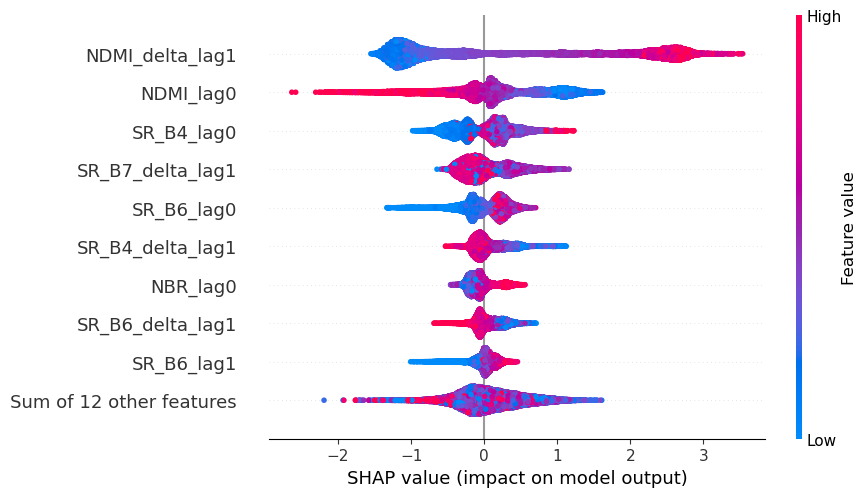

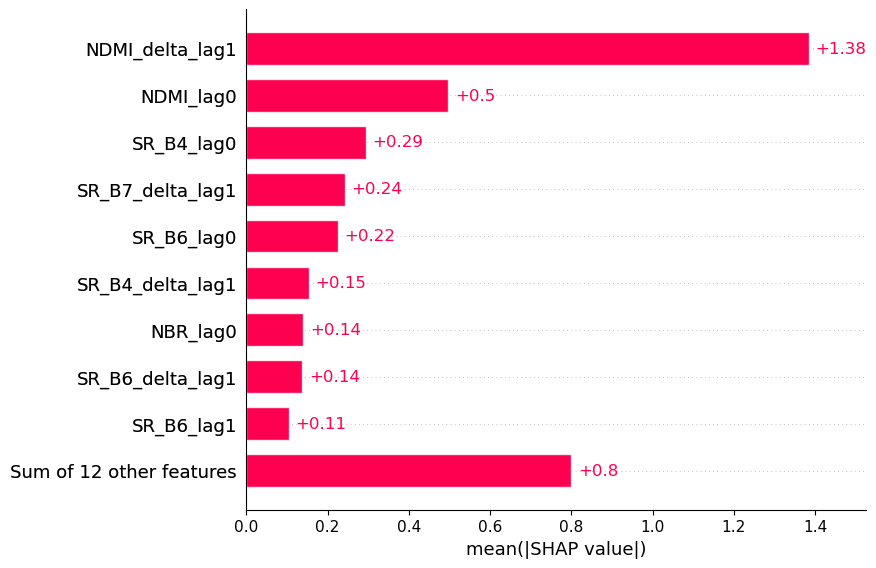

In [13]:
import shap
# Re-fit the tuner on full training data to get a final best estimator for interpretation
tuner.fit(X, y)
best_pipe = tuner.best_estimator_
model = best_pipe.named_steps['model']
explainer = shap.Explainer(model)
# Transform training data for the model component
X_trans = pd.DataFrame(
    best_pipe.named_steps['transformer'].transform(X),
    columns=recent_features,
    index=X.index,
)
shap_values = explainer(X_trans)
# visualize explanations
shap.plots.beeswarm(shap_values)
shap.plots.bar(shap_values)


# Train Model

In [7]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=1)

In [8]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from xgboost import XGBClassifier
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score

In [9]:
xgboost_param_grid = {
    'max_depth': Integer(3, 5),
    'min_child_weight': Integer (1, 200),
    'subsample': Real(0.7, 1),
    'colsample_bylevel': Real(0.5, 1),
    'colsample_bynode': Real(0.5, 1),
    'reg_lambda': Real(0, 10),
    'reg_alpha': Real(0, 10)
}

In [10]:
stage_1_model = XGBClassifier(objective='binary:logistic', random_state=1, learning_rate=0.3, tree_method='hist')

tuner = BayesSearchCV(
    estimator=stage_1_model,
    cv=5,
    refit='f1',
    search_spaces=xgboost_param_grid,
    return_train_score=True,
    random_state=1,
    scoring='f1'
)

In [11]:
tuner.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,search_spaces,"{'colsample_bylevel': Real(low=0.5,...m='normalize'), 'colsample_bynode': Real(low=0.5,...m='normalize'), 'max_depth': Integer(low=3...m='normalize'), 'min_child_weight': Integer(low=1...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,50
,scoring,'f1'
,fit_params,None
,n_jobs,1
,n_points,1
,iid,'deprecated'
,refit,'f1'
,cv,5


In [22]:
print(tuner.best_params_)
params = tuner.best_params_


OrderedDict({'colsample_bylevel': 0.7406236410389274, 'colsample_bynode': 1.0, 'max_depth': 5, 'min_child_weight': 1, 'reg_alpha': 9.027836979874023, 'reg_lambda': 0.0, 'subsample': 1.0})


In [23]:
stage_2_model = XGBClassifier(**params, objective='binary:logistic', random_state=1, learning_rate=0.001, early_stopping_rounds=50, eval_metric="logloss", tree_method='hist')

In [24]:

stage_2_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)], # Required for early stopping
    verbose=True,                     # Shows progress
)

[0]	validation_0-logloss:0.69256
[1]	validation_0-logloss:0.69201
[2]	validation_0-logloss:0.69145
[3]	validation_0-logloss:0.69089
[4]	validation_0-logloss:0.69033
[5]	validation_0-logloss:0.68978
[6]	validation_0-logloss:0.68923
[7]	validation_0-logloss:0.68868
[8]	validation_0-logloss:0.68812
[9]	validation_0-logloss:0.68757
[10]	validation_0-logloss:0.68703
[11]	validation_0-logloss:0.68648
[12]	validation_0-logloss:0.68593
[13]	validation_0-logloss:0.68539
[14]	validation_0-logloss:0.68484
[15]	validation_0-logloss:0.68430
[16]	validation_0-logloss:0.68375
[17]	validation_0-logloss:0.68321
[18]	validation_0-logloss:0.68266
[19]	validation_0-logloss:0.68212
[20]	validation_0-logloss:0.68159
[21]	validation_0-logloss:0.68105
[22]	validation_0-logloss:0.68051
[23]	validation_0-logloss:0.67998
[24]	validation_0-logloss:0.67944
[25]	validation_0-logloss:0.67891
[26]	validation_0-logloss:0.67837
[27]	validation_0-logloss:0.67784
[28]	validation_0-logloss:0.67731
[29]	validation_0-loglos

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,0.7406236410389274
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,1.0
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor

In [25]:
best_round = stage_2_model.best_iteration
print(best_round)
print(stage_2_model.best_score)


99
0.6421194236557263


In [26]:
final_model = XGBClassifier(**params, objective='binary:logistic', random_state=1, learning_rate=0.001, n_estimators=best_round, tree_method='hist')
final_model.fit(X, y)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,0.7406236410389274
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,1.0
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegress

In [27]:
print(f1_score(y, final_model.predict(X)))

0.8558723314147112


In [18]:
import shap
explainer = shap.Explainer(final_model)
# Transform training data for the model component
X_trans = pd.DataFrame(
    final_model.named_steps['transformer'].transform(X_train),
    columns=recent_features,
    index=X_train.index,
)
shap_values = explainer(X_trans)
# visualize explanations
shap.plots.beeswarm(shap_values)
shap.plots.bar(shap_values)


AttributeError: 'XGBClassifier' object has no attribute 'named_steps'

In [ ]:
print(len(X))

53675


# Test On Holdout Set From the Same Region

In [28]:
amazon_test = prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/types/tropical/amazon_test_2025.csv"), 2025)
borneo_test = prepare_data(pd.read_csv("datasets/post_pivot/plus_one/expanded_class/types/tropical/borneo_test_2025.csv"), 2025)
congo_test = prepare_data(pd.read_csv("datasets/post_pivot/plus_one/expanded_class/types/tropical/congo_test_2025.csv"), 2025)

print(len(amazon_test))
print(len(borneo_test))
print(len(congo_test))
print(congo_test['year'].unique())


6000
5845
6000
[2025]


In [29]:
X_test_amazon = amazon_test[recent_features]
y_test_amazon = amazon_test['class']
X_test_borneo = borneo_test[recent_features]
y_test_borneo = borneo_test['class']
X_test_congo = congo_test[recent_features]
y_test_congo = congo_test['class']
print(y_test_borneo.value_counts())

class
1    2954
0    2891
Name: count, dtype: int64


In [30]:
from sklearn.metrics import precision_score, recall_score

print("Amazon Test")
y_test_amazon_pred = final_model.predict(X_test_amazon)
print(f"f1: {f1_score(y_test_amazon, y_test_amazon_pred)}")
print(f"precision: {precision_score(y_test_amazon, y_test_amazon_pred)}")
print(f"recall: {recall_score(y_test_amazon, y_test_amazon_pred)}")

print("Congo Test")
y_test_congo_pred = final_model.predict(X_test_congo)
print(f"f1: {f1_score(y_test_congo, y_test_congo_pred)}")
print(f"precision: {precision_score(y_test_congo, y_test_congo_pred)}")
print(f"recall: {recall_score(y_test_congo, y_test_congo_pred)}")

print("Borneo Test")
y_test_borneo_pred = final_model.predict(X_test_borneo)
print(f"f1: {f1_score(y_test_borneo, y_test_borneo_pred)}")
print(f"precision: {precision_score(y_test_borneo, y_test_borneo_pred)}")
print(f"recall: {recall_score(y_test_borneo, y_test_borneo_pred)}")

print("All Together Test")
X_test = pd.concat([X_test_amazon, X_test_congo, X_test_borneo])
y_test = pd.concat([y_test_amazon, y_test_congo, y_test_borneo])
y_test_pred = final_model.predict(X_test)
print(f"f1: {f1_score(y_test, y_test_pred)}")
print(f"precision: {precision_score(y_test, y_test_pred)}")
print(f"recall: {recall_score(y_test, y_test_pred)}")

Amazon Test
f1: 0.8823013506402385
precision: 0.9311366160681229
recall: 0.8383333333333334
Congo Test
f1: 0.8555537899253138
precision: 0.8174916489523231
recall: 0.8973333333333333
Borneo Test
f1: 0.8216062544420754
precision: 0.8646222887060584
recall: 0.7826675693974272
All Together Test
f1: 0.8533651117920781
precision: 0.8674434702353484
recall: 0.8397364306455215


Models do well!

# Test on New Regions

In [31]:
png_test = prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/types/tropical/png_test_2025.csv"), 2025)

In [32]:
X_test_png = png_test[recent_features]
y_test_png = png_test['class']
print(y_test_png.value_counts())

class
1    2996
0    2899
Name: count, dtype: int64


In [33]:
print("Papua New Guinea Test")
y_test_png_pred = final_model.predict(X_test_png)
print(f"f1: {f1_score(y_test_png, y_test_png_pred)}")
print(f"precision: {precision_score(y_test_png, y_test_png_pred)}")
print(f"recall: {recall_score(y_test_png, y_test_png_pred)}")


Papua New Guinea Test
f1: 0.8098490865766481
precision: 0.7726583813276751
recall: 0.8508010680907877


Tropical model succeeds!

In [ ]:
print(list(final_model.predict_proba(X_test_amazon)))

[array([0.52381027, 0.47618973], dtype=float32), array([0.53563666, 0.46436337], dtype=float32), array([0.53563666, 0.46436337], dtype=float32), array([0.4533044, 0.5466956], dtype=float32), array([0.5335193 , 0.46648067], dtype=float32), array([0.52103794, 0.47896203], dtype=float32), array([0.5048144 , 0.49518558], dtype=float32), array([0.53269863, 0.4673014 ], dtype=float32), array([0.53563666, 0.46436337], dtype=float32), array([0.5355784 , 0.46442157], dtype=float32), array([0.53563666, 0.46436337], dtype=float32), array([0.5334611 , 0.46653888], dtype=float32), array([0.5275797 , 0.47242028], dtype=float32), array([0.4531532, 0.5468468], dtype=float32), array([0.5332371 , 0.46676287], dtype=float32), array([0.53563666, 0.46436337], dtype=float32), array([0.526799  , 0.47320098], dtype=float32), array([0.48074746, 0.51925254], dtype=float32), array([0.5335193 , 0.46648067], dtype=float32), array([0.4531532, 0.5468468], dtype=float32), array([0.4531532, 0.5468468], dtype=float32),

In [34]:
final_model.save_model("../app/ml_models/xgb_tropical.json")